In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import statsmodels.formula.api as smf
import statsmodels.api as sm

In [2]:
# Load data
df = pd.read_csv('Data/Clean/Final-v4.csv')

In [3]:
EU27 = [
    "AUT","BEL","BGR","HRV","CYP","CZE","DNK","EST","FIN","FRA","DEU","GRC",
    "HUN","IRL","ITA","LVA","LTU","LUX","MLT","NLD","POL","PRT","ROU","SVK",
    "SVN","ESP","SWE",
]
OUTSIDE   = ["GBR","CHE","NOR"]
# OUTSIDE   += ["USA"]
COUNTRIES = EU27 + OUTSIDE          # n = 31

# df = df[df["iso3_i"].isin(COUNTRIES) & df["iso3_j"].isin(COUNTRIES)].copy()

In [4]:
df.columns

Index(['iso3_i', 'iso3_j', 'year', 'total_pip_million_usd_i',
       'total_pip_million_usd_j', 'a_ij', 'r_i', 'r_j', 'Y_i', 'k_i', 'L_i',
       'pop_i', 'lab_sh_i', 'delta_i', 'A_i', 'rf_i', 'inv_share_i', 'hc_i',
       'alpha_i', 'Y_j', 'k_j', 'L_j', 'pop_j', 'lab_sh_j', 'delta_j', 'A_j',
       'rf_j', 'inv_share_j', 'hc_j', 'alpha_j', 'euro_i', 'euro_j',
       'total_portfolio_million_usd_i', 'total_portfolio_million_usd_j',
       'bis_debt_i', 'gci_corruption_i', 'gci_financial_composite_i',
       'gci_financial_depth_i', 'gci_financial_stability_i', 'gci_overall_i',
       'gci_trade_openness_i', 'gci_corruption_j', 'gci_financial_composite_j',
       'gci_financial_depth_j', 'gci_financial_stability_j', 'gci_overall_j',
       'gci_trade_openness_j', 'ka_open_i', 'ka_open_j',
       'financial_development_index_i', 'financial_development_index_j',
       'NumEvents', 'NumArticles', 'Sum_NumArticles', 'Sum_NumEvents',
       'Intensity_Articles', 'Log_NumArticles', 'Log_NumE

In [5]:
num_cols = df.select_dtypes(include=[np.number]).columns
df[num_cols].corrwith(df["a_ij"]).sort_values(ascending=False, key=abs).head(10)

a_ij                             1.000000
NumEvents                        0.457783
d_numevents                     -0.457783
total_pip_million_usd_j          0.427103
total_portfolio_million_usd_j    0.379004
total_pip_million_usd_i          0.368040
k_j                              0.338986
Log_NumEvents                    0.332140
total_portfolio_million_usd_i    0.330907
language_proximity               0.330720
dtype: float64

In [6]:
# df["d_ling"] = 1 - df["lang_share"]
# df["ln_d_geo"] = np.log(df["d_geo"])
# df["ln_a_ij"] = np.log1p(df["a_ij"])
# df["euro_ij"] = df["euro_i"] * df["euro_j"]

# # Replace inf with nan in ln_d_geo
# df = df.replace([np.inf, -np.inf], np.nan)

In [7]:
# # Standardise each component to [0, 1] range
# geo_norm = (df['ln_d_geo'] - df['ln_d_geo'].min()) / (df['ln_d_geo'].max() - df['ln_d_geo'].min())
# ling_norm = df['d_ling']  # already 0-1
# cul_norm = df['d_cul'] / df['d_cul'].max()  # scale to 0-1

# # Composite: average of available components
# df['d_composite'] = pd.concat([geo_norm, ling_norm, cul_norm], axis=1).mean(axis=1, skipna=True)

In [26]:
df["d_gci_overall"] = np.abs(df["gci_overall_i"] - df["gci_overall_j"])
df["d_gci_corruption"] = np.abs(df["gci_corruption_i"] - df["gci_corruption_j"])
df["d_gci_trade_openness"] = np.abs(df["gci_trade_openness_i"] - df["gci_trade_openness_j"])
df["d_gci_financial_composite"] = np.abs(df["gci_financial_composite_i"] - df["gci_financial_composite_j"])
df["d_gci_financial_depth"] = np.abs(df["gci_financial_depth_i"] - df["gci_financial_depth_j"])
df["d_gci_financial_stability"] = np.abs(df["gci_financial_stability_i"] - df["gci_financial_stability_j"])
df["d_ka_open"] = np.abs(df["ka_open_i"] - df["ka_open_j"])
df["euro_ij"] = df["euro_i"] * df["euro_j"]
df["eu_ij"] = ((df["iso3_i"].isin(EU27)) & (df["iso3_j"].isin(EU27))).astype(int)
df["d_legal_origin"] = (df["legal_origin_i"] != df["legal_origin_j"]).astype(int)
df["d_financial_development_index"] = np.abs(df["financial_development_index_i"] - df["financial_development_index_j"])



ppml_df = df[df["iso3_i"] != df["iso3_j"]].copy()
ppml_df = ppml_df[ppml_df["iso3_i"].isin(COUNTRIES) & ppml_df["iso3_j"].isin(COUNTRIES)].copy()

# Construct the pairs
ppml_df["pair"] = ppml_df.apply(lambda row: '_'.join(sorted([row['iso3_i'], row['iso3_j']])), axis=1)

cols = ["a_ij", "d_ling", "d_financial_development_index", "d_num_articles", "d_geo", "year", "iso3_i", "iso3_j", "Y_i", "Y_j"]

# Create bilateral pair identifier for clustering
ppml_df['pair'] = ppml_df['iso3_i'] + '_' + ppml_df['iso3_j']

# Drop rows with missing covariates; keep zero a_ij (PPML handles zeros correctly)
ppml_df = ppml_df.dropna(subset=cols).copy()
# Fill nan with zeros for covariates (if any remain); PPML can handle zeros but not nans
# ppml_df[cols] = ppml_df[cols].fillna(0)

# Change Y to /1e3 and round to reduce massive numbers in interaction term
ppml_df["Y_i"] = ppml_df["Y_i"].div(1e6).round(3)
ppml_df["Y_j"] = ppml_df["Y_j"].div(1e6).round(3)
ppml_df["a_ij"] = ppml_df["a_ij"].div(1e6).round(3)

# PPML requires non-negative (not strictly positive) a_ij — zero flows are valid
ppml_df["a_ij"] = ppml_df["a_ij"].clip(lower=0)

num_cols = ppml_df[cols].select_dtypes(include=[np.number]).columns

n_zeros = (ppml_df["a_ij"] == 0).sum()
n_pos   = (ppml_df["a_ij"]  > 0).sum()
print(f"Sample: {len(ppml_df):,} obs  |  positive: {n_pos:,}  |  zeros: {n_zeros:,}")

formula = 'a_ij ~ d_ling + d_num_articles + d_financial_development_index + d_geo + Y_i + Y_j + C(year)'
model = smf.poisson(
    formula=formula,
    data=ppml_df,
).fit(
    method="newton",      # Use Newton-Raphson instead of BFGS
    maxiter=300,
    cov_type="cluster",
    cov_kwds={"groups": ppml_df['pair']},
)

print(model.summary())


Sample: 2,858 obs  |  positive: 1,691  |  zeros: 1,167
Optimization terminated successfully.
         Current function value: 0.069133
         Iterations 9
                          Poisson Regression Results                          
Dep. Variable:                   a_ij   No. Observations:                 2858
Model:                        Poisson   Df Residuals:                     2846
Method:                           MLE   Df Model:                           11
Date:                Thu, 07 May 2026   Pseudo R-squ.:                  0.2488
Time:                        11:28:20   Log-Likelihood:                -197.58
converged:                       True   LL-Null:                       -263.01
Covariance Type:              cluster   LLR p-value:                 1.163e-22
                                    coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------------------------
Intercept      

In [10]:
# Save gravity model predictions alongside actuals
pred_df = ppml_df[["iso3_i", "iso3_j", "year", "a_ij"]].copy()
pred_df["a_ij_pred"] = model.predict(ppml_df)

pred_df.to_csv("v4-gravity_pred.csv", index=False)
print(f"Saved {len(pred_df):,} rows to v4-gravity_pred.csv")
print(pred_df.head())

Saved 2,858 rows to v4-gravity_pred.csv
      iso3_i iso3_j  year   a_ij  a_ij_pred
82695    AUT    BGR  2015  0.000   0.002891
82696    AUT    BGR  2016  0.000   0.002460
82697    AUT    BGR  2017  0.001   0.002923
82698    AUT    BGR  2018  0.000   0.002445
82699    AUT    BGR  2019  0.000   0.002964


In [11]:
# plot the d_ling, numarticles, d_gci_financial_composite coefficients scatter matrix
from pandas.plotting import scatter_matrix

scat_df = df[["d_ling", "d_geo", "d_financial_development_index", "d_num_articles", "a_ij"]]
# scatter_matrix(scat_df, alpha=0.2, figsize=(10, 10), diagonal='kde')
# plt.suptitle("Scatter Matrix of Key Variables")
# plt.show()

scat_df.isna().mean()

d_ling                           0.361801
d_geo                            0.064658
d_financial_development_index    0.728061
d_num_articles                   0.953836
a_ij                             0.987432
dtype: float64

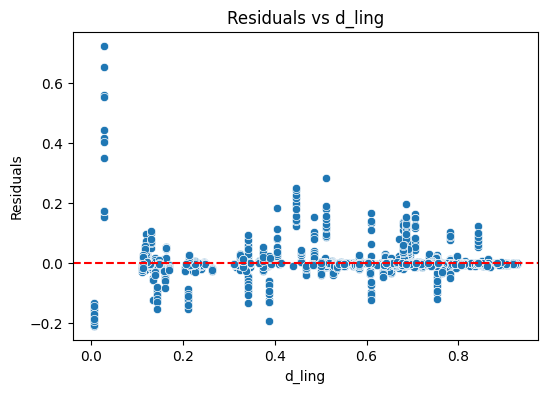

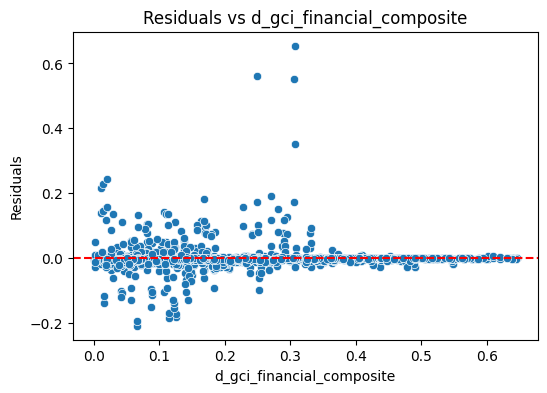

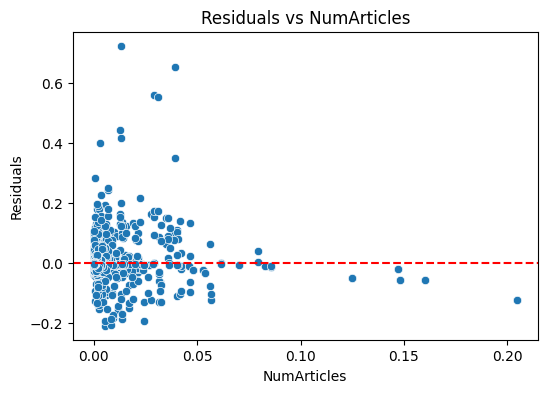

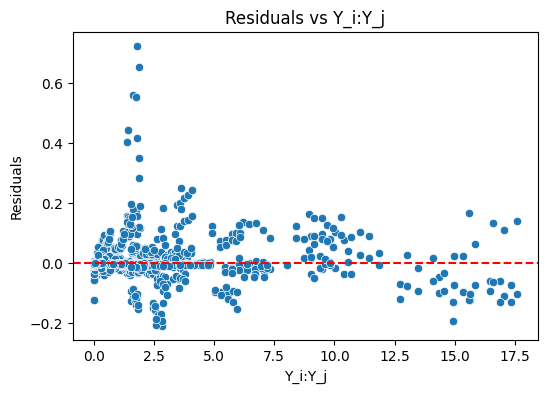

In [12]:
# plot scatter plots of residual against all of the variables in the model
residuals = model.resid_response
ppml_df["Y_i:Y_j"] = ppml_df["Y_i"] * ppml_df["Y_j"]

for col in ["d_ling", "d_gci_financial_composite", "NumArticles", "Y_i:Y_j"]:
    plt.figure(figsize=(6, 4))
    sns.scatterplot(x=ppml_df[col], y=residuals)
    plt.title(f"Residuals vs {col}")
    plt.xlabel(col)
    plt.ylabel("Residuals")
    plt.axhline(0, color='red', linestyle='--')
    plt.show()

In [13]:
# Control-function endogeneity test for d_num_articles
# Instrument: leave-one-out destination-year mean (z_loo)
# Both stages mirror the main PPML: same controls, same sample, pair-clustered SEs.

_EXOG = "d_ling + d_gci_financial_depth + d_gci_financial_stability + d_geo + Y_i + Y_j + C(year) + C(iso3_i) + C(iso3_j)"

# Build instrument
dwh_df = ppml_df.copy()
grp = dwh_df.groupby(["iso3_j", "year"])["d_num_articles"].agg(["sum", "count"]).reset_index()
dwh_df = dwh_df.merge(grp, on=["iso3_j", "year"])
dwh_df["z_loo"] = (dwh_df["sum"] - dwh_df["d_num_articles"]) / (dwh_df["count"] - 1).clip(1)
dwh_df = dwh_df.dropna(subset=["z_loo"]).copy()

# Stage 1: OLS for d_num_articles (linear first stage is standard)
fs = smf.ols(
    f"d_num_articles ~ z_loo + {_EXOG}",
    data=dwh_df,
).fit(cov_type="cluster", cov_kwds={"groups": dwh_df["pair"]})

print(f"First-stage F on z_loo: {fs.tvalues['z_loo']**2:.2f}  "
      f"(coeff={fs.params['z_loo']:+.4f}, p={fs.pvalues['z_loo']:.4f})")
print("Weak-instrument threshold: F > 10")

dwh_df["v_hat"] = fs.resid

# Stage 2: Augmented PPML (control-function / 2SRI)
# H0: rho = 0  => d_num_articles is exogenous
aug = smf.poisson(
    f"a_ij ~ d_num_articles + v_hat + {_EXOG}",
    data=dwh_df,
).fit(
    method="newton", maxiter=300, disp=False,
    cov_type="cluster", cov_kwds={"groups": dwh_df["pair"]},
)

print(f"\nControl-function test (augmented PPML):")
print(f"  rho_hat = {aug.params['v_hat']:+.4f}   p = {aug.pvalues['v_hat']:.4f}")
print(f"  -> {'REJECT exogeneity: d_num_articles is ENDOGENOUS' if aug.pvalues['v_hat'] < 0.05 else 'Fail to reject: no strong evidence of endogeneity'}")


ValueError: The weights and list don't have the same length.

In [ ]:
# Full augmented PPML summary
print(aug.summary())


                          Poisson Regression Results                          
Dep. Variable:                   a_ij   No. Observations:                 1614
Model:                        Poisson   Df Residuals:                     1549
Method:                           MLE   Df Model:                           64
Date:                Mon, 04 May 2026   Pseudo R-squ.:                  0.4489
Time:                        12:50:44   Log-Likelihood:                -130.91
converged:                       True   LL-Null:                       -237.55
Covariance Type:              cluster   LLR p-value:                 6.090e-18
                                coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------------------
Intercept                    -4.7818      1.795     -2.665      0.008      -8.299      -1.264
C(year)[T.2018]              -0.0328      0.019     -1.708      0.088      -0.070     

In [ ]:
# Control-function endogeneity test for d_num_articles
# Instrument: leave-one-out destination-year mean

_EXOG = (
    "d_ling + d_gci_financial_depth + d_gci_financial_stability + "
    "d_geo + Y_i + Y_j + C(year) + C(iso3_i) + C(iso3_j)"
)

dwh_df = ppml_df.copy()

grp = (
    dwh_df
    .groupby(["iso3_j", "year"])["d_num_articles"]
    .agg(group_sum="sum", group_count="count")
    .reset_index()
)

dwh_df = dwh_df.merge(grp, on=["iso3_j", "year"], how="left")

den = dwh_df["group_count"] - 1
dwh_df["z_loo"] = np.where(
    den > 0,
    (dwh_df["group_sum"] - dwh_df["d_num_articles"]) / den,
    np.nan
)

dwh_df = dwh_df.dropna(subset=["z_loo"]).copy()

# First stage
fs = smf.ols(
    f"d_num_articles ~ z_loo + {_EXOG}",
    data=dwh_df
).fit(
    cov_type="cluster",
    cov_kwds={"groups": dwh_df["pair"]}
)

wald = fs.wald_test("z_loo = 0", scalar=True)

print("First-stage relevance check:")
print(f"  z_loo coefficient = {fs.params['z_loo']:+.4f}")
print(f"  clustered p-value = {fs.pvalues['z_loo']:.4f}")
print(f"  Wald statistic = {float(wald.statistic):.2f}")
print("  Note: this is not a full robust weak-IV diagnostic.")

dwh_df["v_hat"] = fs.resid

# Augmented PPML / control-function test
aug = smf.poisson(
    f"a_ij ~ d_num_articles + v_hat + {_EXOG}",
    data=dwh_df
).fit(
    method="newton",
    maxiter=300,
    disp=False,
    cov_type="cluster",
    cov_kwds={"groups": dwh_df["pair"]}
)

print("\nControl-function endogeneity test:")
print(f"  coefficient on v_hat = {aug.params['v_hat']:+.4f}")
print(f"  clustered p-value    = {aug.pvalues['v_hat']:.4f}")

if aug.pvalues["v_hat"] < 0.05:
    print("  Result: reject exogeneity at the 5% level.")
else:
    print("  Result: fail to reject exogeneity at the 5% level.")

First-stage relevance check:
  z_loo coefficient = -5.1154
  clustered p-value = 0.0000
  Wald statistic = 39.97
  Note: this is not a full robust weak-IV diagnostic.

Control-function endogeneity test:
  coefficient on v_hat = -3.0936
  clustered p-value    = 0.0436
  Result: reject exogeneity at the 5% level.
